In [ ]:
!nvidia-smi

Wed Aug 26 21:52:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd /content
!rm -rf SiteGuard-Vision
!git clone https://github.com/YasserAlasiri/SiteGuard-Vision.git
%cd SiteGuard-Vision
!ls

/content
Cloning into 'SiteGuard-Vision'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 109 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 52.50 KiB | 5.83 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/SiteGuard-Vision
app.py	   assets   docs       README.md	 run_pipeline.py  tests
artifacts  configs  notebooks  requirements.txt  src


In [ ]:
!pip install -q -U ultralytics onnx onnxslim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 9.1 MB/s eta 0:00:00


In [ ]:
!python src/train.py --device 0 --epochs 3


Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_train, nbs=64, nms=False, opset=None

In [ ]:
!ln -sfn /content/SiteGuard-Vision/runs/detect/runs/siteguard /content/SiteGuard-Vision/runs/siteguard
!ls -l runs/siteguard/ppe_train/weights/

total 10528
-rw-r--r-- 1 root root 5389701 Aug 26 21:55 best.pt
-rw-r--r-- 1 root root 5389701 Aug 26 21:55 last.pt


In [ ]:
!python src/evaluate.py

import json
print(json.dumps(json.load(open('artifacts/evaluation_metrics.json')), indent=2))

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1829.8±490.1 MB/s, size: 87.6 KB)


                   all        143       1172      0.347      0.135      0.114     0.0585
                helmet        107        201      0.609      0.458      0.307       0.15
                gloves         68        136      0.577      0.331      0.271      0.141
                  vest        109        171      0.875      0.123      0.119     0.0685
                 boots         64        151      0.864      0.126      0.115     0.0708
               goggles         44         47          0          0          0          0
                  none         43         81          0          0          0          0
                Person        139        239      0.893      0.452      0.441      0.214
             no_helmet         27  

In [ ]:
!python src/analyze_training.py
print(open('artifacts/training_analysis.md', encoding='utf-8').read())

Wrote artifacts/training_analysis.md
# Training Run Analysis

- Epochs completed: 3
- Best validation mAP50-95 epoch: 3
- Best validation mAP50-95: 0.12953
- Final validation mAP50-95: 0.12953
- Assessment: No automatic conclusion; inspect curves.

## Hyperparameter rationale
- Image size 640 balances PPE detail and training cost.
- Early stopping patience=12 protects against unnecessary over-training.
- Pretrained weights improve convergence on the 1,416-image domain dataset.
- Default Ultralytics augmentations are retained first; if validation stalls, tune augmentation and learning rate based on the curves rather than guessing.

Final train box loss: 1.74261
Final val box loss: 1.73273


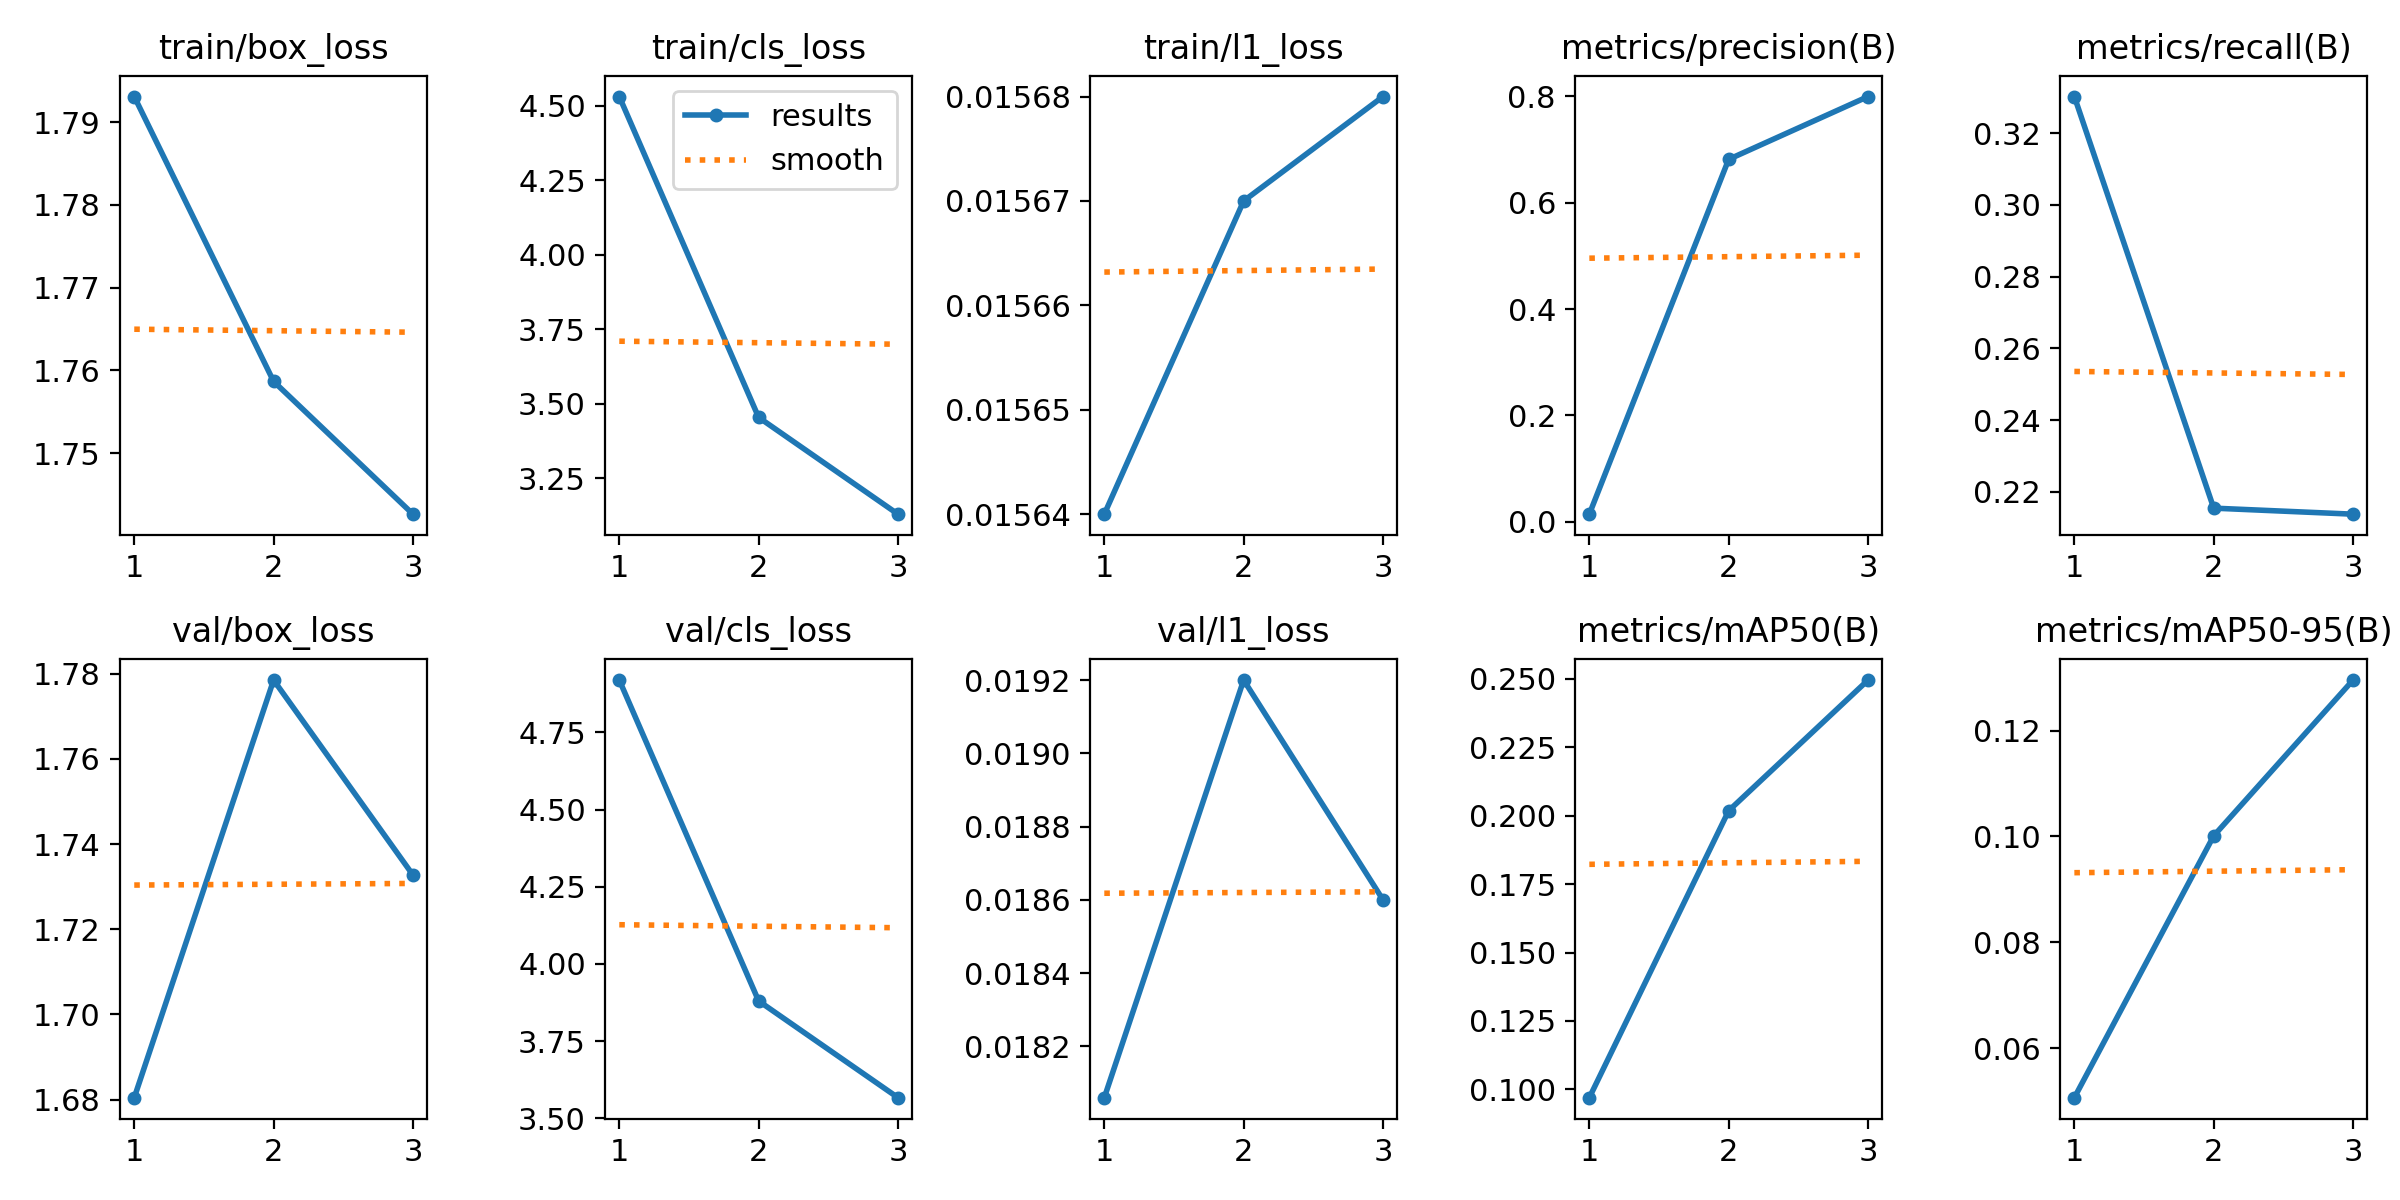

runs/siteguard/ppe_train/results.png


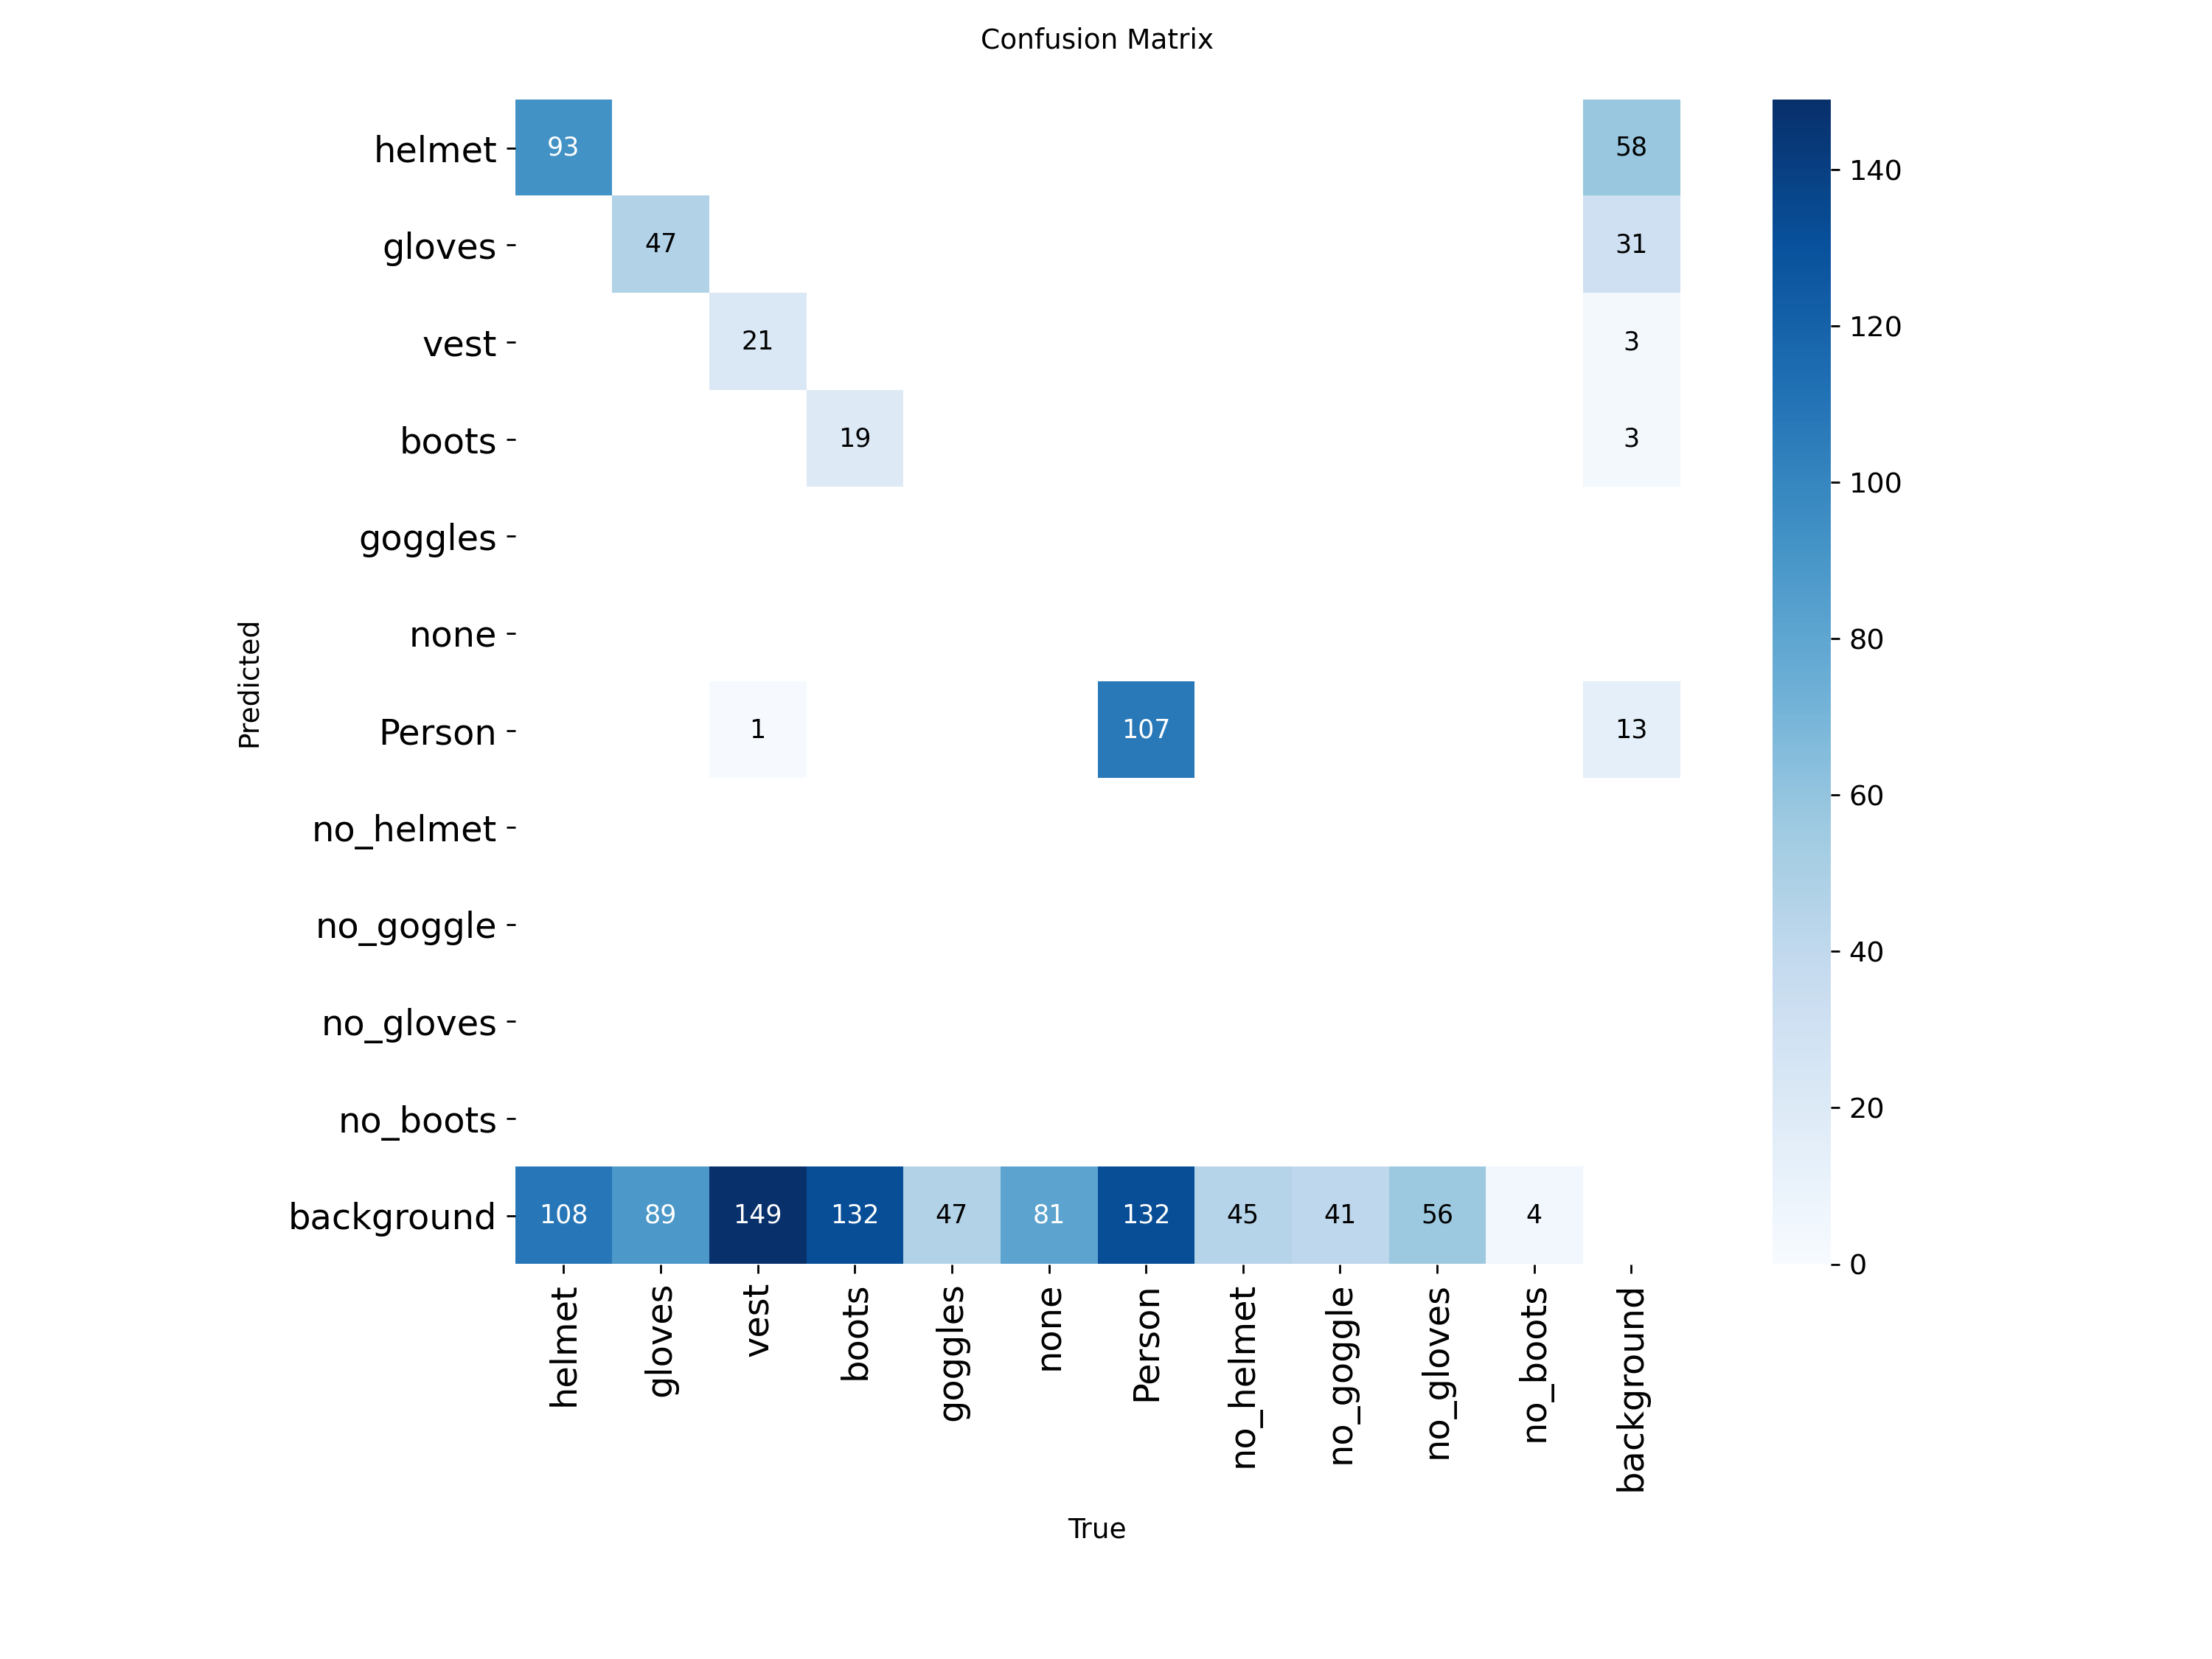

runs/siteguard/evaluation/confusion_matrix.png


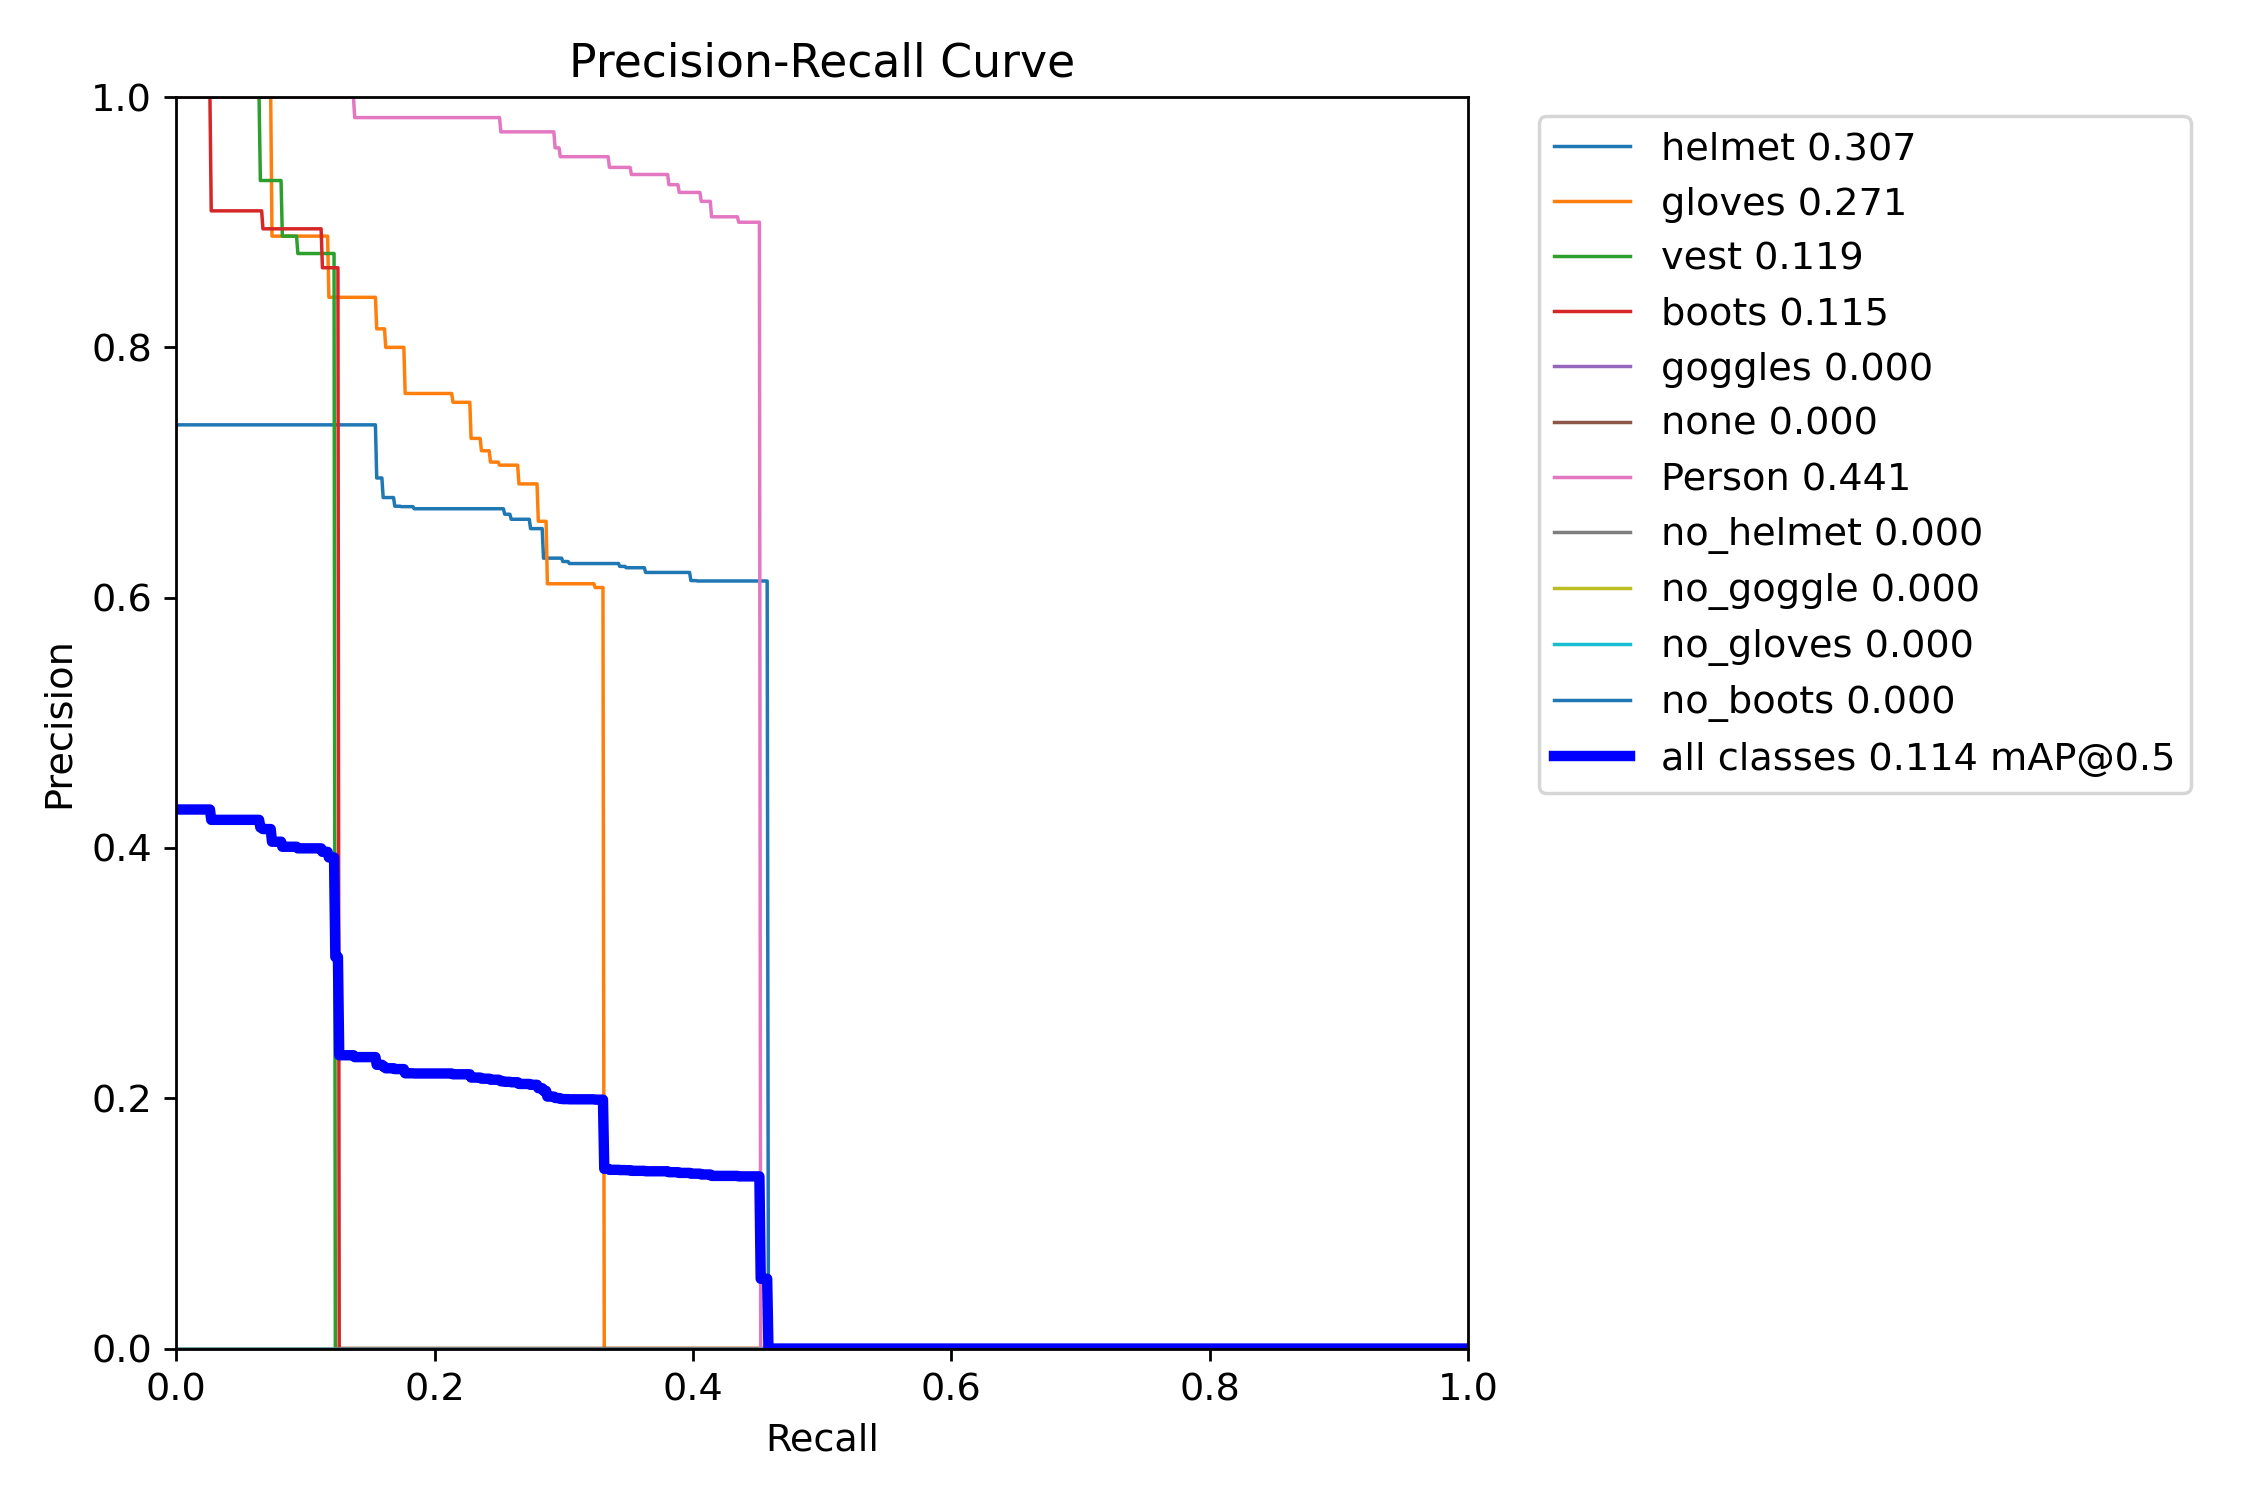

runs/siteguard/evaluation/BoxPR_curve.png


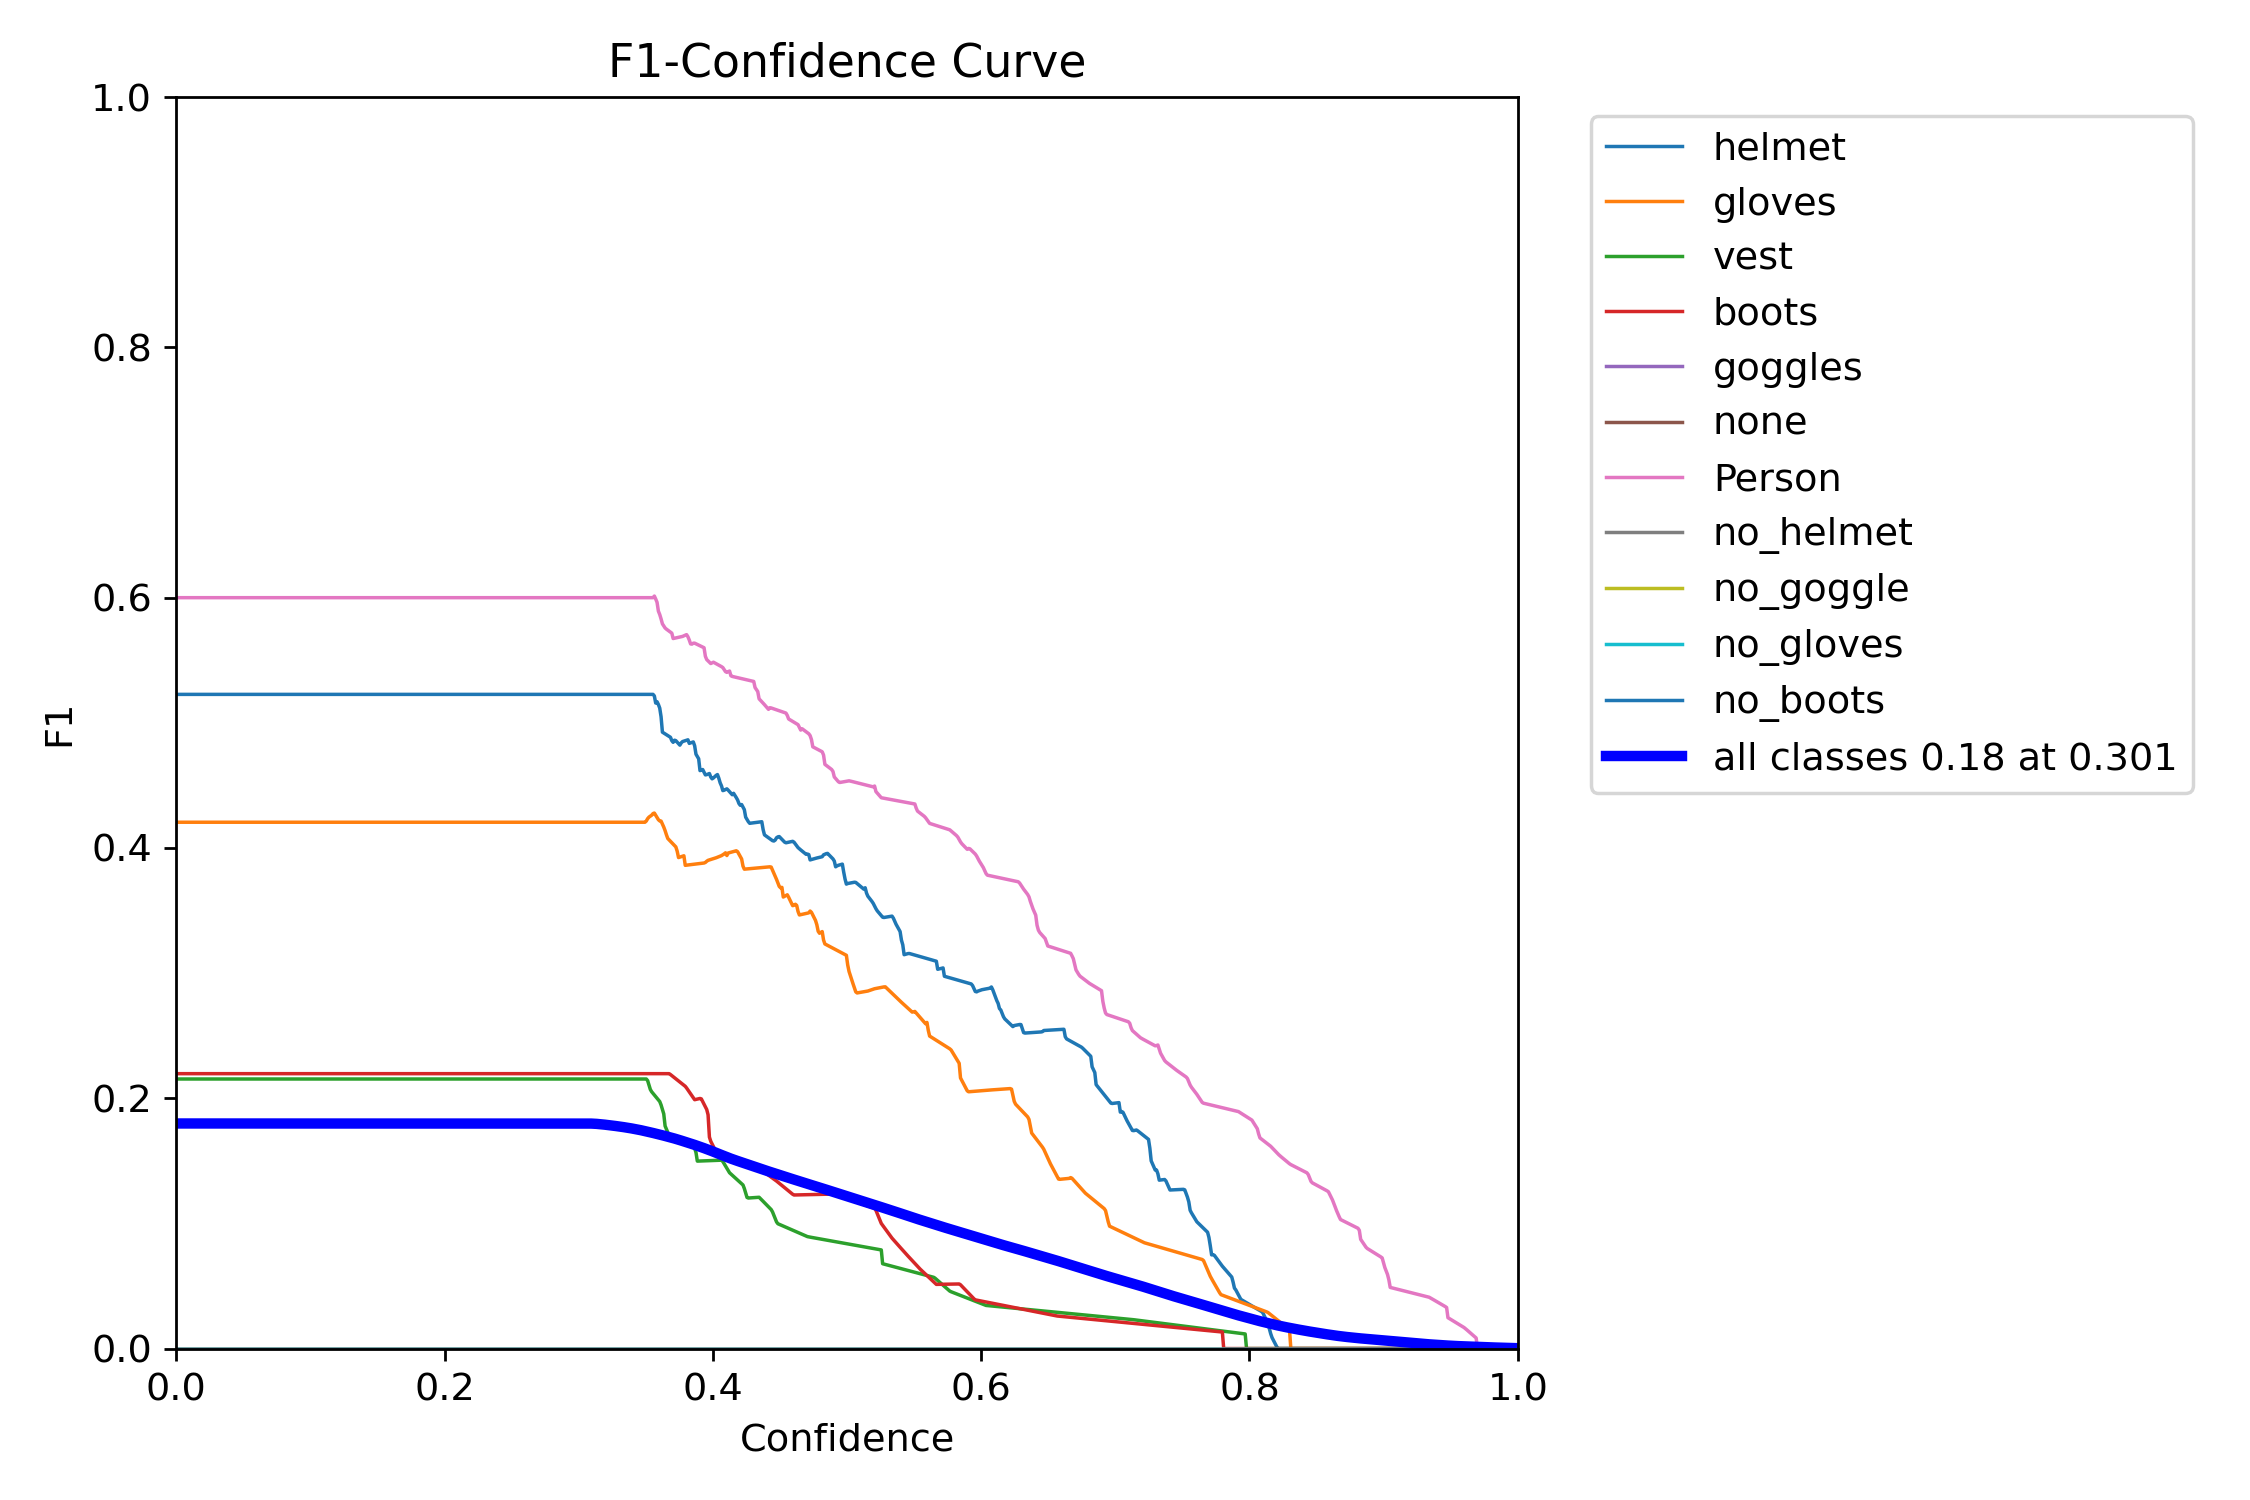

runs/siteguard/evaluation/BoxF1_curve.png


In [ ]:
import os
from IPython.display import Image, display

for p in ['runs/siteguard/ppe_train/results.png',
          'runs/siteguard/evaluation/confusion_matrix.png',
          'runs/siteguard/evaluation/BoxPR_curve.png',
          'runs/siteguard/evaluation/BoxF1_curve.png']:
    print(p) if os.path.exists(p) and display(Image(p, width=760)) is None else print('مو موجود:', p)

In [ ]:
!python src/export_model.py
!ls -lh runs/siteguard/ppe_train/weights/

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from 'runs/siteguard/ppe_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 311ms
Prepared 1 package in 460ms
Installed 1 package in 7ms
 + onnxruntime==1.29.0

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 3.2s, saved as 'runs/siteguard/ppe_train/weights/best.onnx' (9

Saving 555555.png to 555555.png

image 1/1 /content/SiteGuard-Vision/555555.png: 416x640 3 helmets, 2 Persons, 10.8ms
Speed: 21.1ms preprocess, 10.8ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/SiteGuard-Vision/runs/detect/runs/siteguard/inference
1 label saved to /content/SiteGuard-Vision/runs/detect/runs/siteguard/inference/labels
Inference complete. Detections: 5
Annotated output: runs/siteguard/inference/


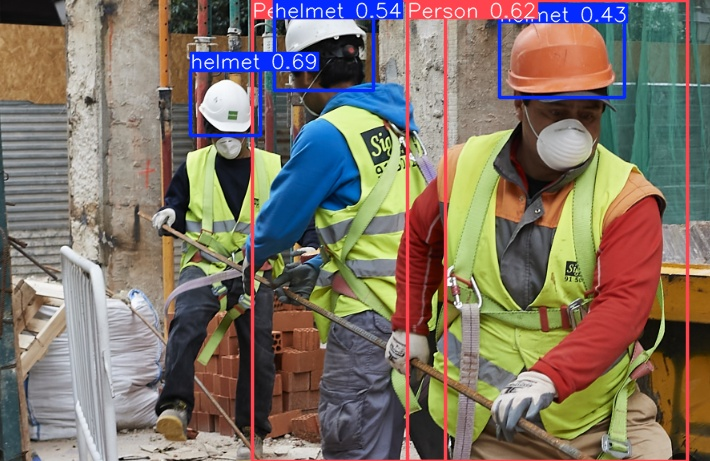

In [ ]:
from google.colab import files
import os, glob
from IPython.display import Image, display

up = files.upload()
img = os.path.abspath(list(up.keys())[0])

!python src/inference.py --source "{img}"

for f in sorted(glob.glob('runs/siteguard/inference/*.jpg')):
    display(Image(f, width=800))

In [ ]:
import glob
from IPython.display import Image, display

!python src/segmentation_demo.py --source "{img}"

for f in sorted(glob.glob('runs/siteguard/segmentation/*.jpg')):
    display(Image(f, width=800))



image 1/1 /content/SiteGuard-Vision/555555.png: 416x640 3 persons, 16.4ms
Speed: 26.9ms preprocess, 16.4ms inference, 10.2ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/SiteGuard-Vision/runs/segment/runs/siteguard/segmentation
Segmentation complete. Total instance masks: 3
Saved annotated output to runs/siteguard/segmentation


In [ ]:
from google.colab import files
import json

up = files.upload()
vid = list(up.keys())[0]

!python src/video_analytics.py --source "{vid}"
print(json.dumps(json.load(open('artifacts/video_analytics_summary.json')), indent=2))

Saving cons.mp4 to cons.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 203ms
Prepared 1 package in 58ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

{'source': 'cons.mp4', 'frames_processed': 1206, 'unique_track_ids_seen': 75, 'unique_person_zone_entries': 27, 'violation_detections_by_class': {}, 'total_violation_detections': 0, 'output_video': 'artifacts/siteguard_analytics.mp4', 'note': 'Violation counts are frame-level detection events; zone entry count uses persistent Person track IDs.'}
{
  "source": "cons.mp4",
  "frames_processed": 1206,
  "unique_track_ids_seen": 75,
  "unique_person_zone_entries": 27,
  "violation_detections_by_class": {},
  "total_violation_detections": 0,
  "output_video": "artifacts/siteguard_analytics.mp4",
  "note": "Violat

In [ ]:
!find /content -type f \( -name "*.mp4" -o -name "*.avi" \) | tail -20

/content/SiteGuard-Vision/artifacts/siteguard_analytics.mp4
/content/SiteGuard-Vision/cons.mp4


In [ ]:
from IPython.display import Video

Video("/content/SiteGuard-Vision/cons.mp4", embed=True)

In [ ]:
!ffmpeg -y -loglevel error -i artifacts/siteguard_analytics.mp4 -vcodec libx264 -crf 23 -pix_fmt yuv420p /content/out.mp4

from IPython.display import Video
Video("/content/out.mp4", embed=True, width=800)

In [ ]:
!python src/export_model.py

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from 'runs/siteguard/ppe_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.2s, saved as 'runs/siteguard/ppe_train/weights/best.onnx' (9.4 MB)

Export complete (2.7s)
Results saved to /content/SiteGuard-Vision/runs/detect/runs/siteguard/ppe_train/weights/best.onnx
Predict:         yolo predict task=detect model=runs/siteguard/ppe_train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/siteguard/ppe_train/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.13/dist-packages/ultralytics/cfg/datasets/construction-ppe.yaml  
Visualize:       https://netron.app
ONNX export complete: runs/siteguard/ppe_train/we